# 11-SLOs, Error Budgets & Alerting (Alertmanager)

In Lesson 10, we mastered log aggregation with Grafana Loki, giving us the ability to instantly triage the exact stack traces causing ML failures. Between Prometheus metrics and Loki logs, our observability stack is fundamentally complete.

However, a dashboard is fundamentally a **passive** system. It requires a human engineer to sit and stare at a screen. If an LLM starts hallucinating at 3:00 AM on a Sunday, your perfectly engineered Grafana dashboard will turn red, but no one will be awake to see it.

To transition from passive monitoring to **active Site Reliability Engineering (SRE)**, we must implement automated alerting. We do not trigger alerts based on arbitrary server metrics like "CPU > 80%." Instead, we engineer alerts strictly around mathematical **Service Level Objectives (SLOs)** and **Error Budgets**. We will define these rules in Prometheus and use **Alertmanager** to route critical breaches directly to automated on-call systems.

# 1. The Mathematics of SRE: SLIs, SLOs, and Error Budgets

Google's SRE framework replaces subjective opinions about system reliability with strict mathematical definitions.

### The Service Level Indicator (SLI)

An SLI is a continuous mathematical measurement of a specific user-facing metric. It is almost always formulated as a ratio of "good" events to total events:


$$\text{SLI} = \frac{\text{Valid Inference Requests}}{\text{Total Inference Requests}}$$


If an SLI drops, the user is directly experiencing pain (e.g., timeouts, $500$ errors, severe latency).

### The Service Level Objective (SLO)

The SLO is the strict mathematical target we set for the SLI over a rolling temporal window (usually 30 days).
If our target is "three nines" (99.9%) for latency:


$$\text{SLO}: P(\text{Latency} \le 250\text{ms}) \ge 0.999 \quad \text{over 30 days}$$

### The Error Budget

Perfection (100% uptime) is mathematically impossible in distributed computing and financially ruinous to attempt. The Error Budget is the exact mathematical inverse of the SLO. It dictates exactly how much unreliability we are permitted to experience:


$$\text{Error Budget} = 1 - \text{SLO}$$


For a 99.9% SLO over 30 days, our error budget is $0.1\%$.
$30 \text{ days} \times 24 \text{ hours} \times 60 \text{ minutes} = 43,200 \text{ minutes}$.


$$\text{Error Budget (Time)} = 43,200 \times 0.001 = 43.2 \text{ minutes of allowed failure per month.}$$

### The Burn Rate Vector

We do not alert when the error budget hits zero (that is too late). We alert on the **Burn Rate**—the mathematical derivative of the error budget consumption.


$$\text{Burn Rate} = \frac{\text{Current Error Rate}}{\text{Allowed Error Rate}}$$


If the Burn Rate is $1$, we will consume our entire budget in exactly 30 days. If the Burn Rate spikes to $10$, we will consume our entire 30-day budget in 3 days. A Burn Rate $\ge 10$ over a 1-hour window mathematically triggers a Page to wake up the on-call engineer.

# 2. Imperative Execution: Compiling Prometheus Alert Rules

Prometheus continuously evaluates PromQL expressions. We can configure Prometheus to transition from a pure database into a state engine by supplying it with a declarative `rules.yml` file containing our math.

In [1]:
import os

print("--- 🚀 Initializing SRE Alerting Sandbox ---")

alert_sandbox = "./alerting_sandbox"
os.makedirs(alert_sandbox, exist_ok=True)

# 1. 📝 Compile the Mathematical Alerting Rules
prometheus_rules = """
groups:
  - name: mlops_slo_alerts
    rules:
      # 🚨 Rule 1: The Hard Availability Breach (Total System Failure)
      - alert: InferenceAPI_Offline
        expr: up{job="local_llm_engine"} == 0
        for: 1m  # The mathematical condition must persist for 1 minute to avoid false positives
        labels:
          severity: critical
          team: ml-infrastructure
        annotations:
          summary: "CRITICAL: Inference Engine is offline."
          description: "The Prometheus scraper cannot reach the LLM container."

      # 🚨 Rule 2: The Latency Error Budget Burn (SRE)
      - alert: HighLatency_BurnRate_Breach
        # This PromQL expression mathematically detects if the ratio of SLOW requests 
        # to TOTAL requests exceeds 5% over a 5-minute rolling window.
        expr: |
          (
            sum(rate(llm_latency_seconds_bucket{le="2.5"}[5m])) 
            / 
            sum(rate(llm_latency_seconds_count[5m]))
          ) < 0.95
        for: 2m
        labels:
          severity: page
          team: ml-engineering
        annotations:
          summary: "SLA BREACH: P99 Latency exceeds 2.5 seconds."
          description: "The error budget is burning at 10x normal rate. The GPU queue is completely saturated."
"""

rules_path = os.path.join(alert_sandbox, "alert_rules.yml")
with open(rules_path, "w") as f:
    f.write(prometheus_rules.strip())

print(f"   ✅ SRE Alerting Rules Compiled: {rules_path}")
print("   -> Physics: Every 15 seconds, Prometheus runs these formulas against the live RAM vectors.")
print("   -> If an expression evaluates to True, the alert transitions to a 'FIRING' state.")

--- 🚀 Initializing SRE Alerting Sandbox ---
   ✅ SRE Alerting Rules Compiled: ./alerting_sandbox/alert_rules.yml
   -> Physics: Every 15 seconds, Prometheus runs these formulas against the live RAM vectors.
   -> If an expression evaluates to True, the alert transitions to a 'FIRING' state.


# 3. Declarative Execution: The Alertmanager Topology

Prometheus detects the breach, but it does not send emails or Slack messages. It forwards the `FIRING` payload to a dedicated microservice called **Alertmanager**.

Alertmanager deduplicates the alerts, groups them (so 1,000 failing containers only send 1 Slack message, not 1,000), and routes them to specific receiver endpoints based on the `team` or `severity` labels.

In [2]:
import yaml

print("\n--- ⚡ Compiling Alertmanager Routing Matrix ---")

# 1. 📝 Compile the Alertmanager Configuration
alertmanager_config = """
global:
  resolve_timeout: 5m

# The Routing Tree
route:
  group_by: ['alertname', 'team']
  group_wait: 10s       # Wait 10s to batch simultaneous alerts together
  group_interval: 1m    # Send updates every 1m
  repeat_interval: 1h   # Remind us every hour if not resolved
  
  # Default receiver
  receiver: 'slack_mlops_alerts'
  
  # Child routes for specialized handling
  routes:
    - match:
        severity: critical
      receiver: 'pagerduty_oncall'  # Wake someone up in the middle of the night

# The Endpoints (Mocked for local execution)
receivers:
  - name: 'slack_mlops_alerts'
    webhook_configs:
      - url: 'http://localhost:9099/mock-slack-webhook'
  
  - name: 'pagerduty_oncall'
    webhook_configs:
      - url: 'http://localhost:9099/mock-pagerduty'
"""

am_path = os.path.join(alert_sandbox, "alertmanager.yml")
with open(am_path, "w") as f:
    f.write(alertmanager_config.strip())

# 2. 📝 Update the Compose blueprint to include Alertmanager
alert_compose = {
    "version": "3.8",
    "services": {
        "alertmanager": {
            "image": "prom/alertmanager:latest",
            "container_name": "mlops_alertmanager",
            "ports": ["9093:9093"],
            "volumes": [f"./alertmanager.yml:/etc/alertmanager/alertmanager.yml"],
            "command": "--config.file=/etc/alertmanager/alertmanager.yml"
        }
    }
}

compose_path = os.path.join(alert_sandbox, "docker-compose.yml")
with open(compose_path, "w") as f:
    yaml.dump(alert_compose, f, default_flow_style=False)

print(f"   ✅ Alertmanager Configuration Compiled: {am_path}")
print(f"   ✅ Alertmanager Docker Compose Matrix updated: {compose_path}")


--- ⚡ Compiling Alertmanager Routing Matrix ---
   ✅ Alertmanager Configuration Compiled: ./alerting_sandbox/alertmanager.yml
   ✅ Alertmanager Docker Compose Matrix updated: ./alerting_sandbox/docker-compose.yml


# 4. Visualizing Error Budget Depletion (The Burn Down Chart)

To understand exactly when an alert is fired, we must visualize the physical depletion of the Error Budget. Alertmanager does not trigger when the system breaks slightly; it triggers when the *slope* of the failure curve becomes mathematically unsustainable.

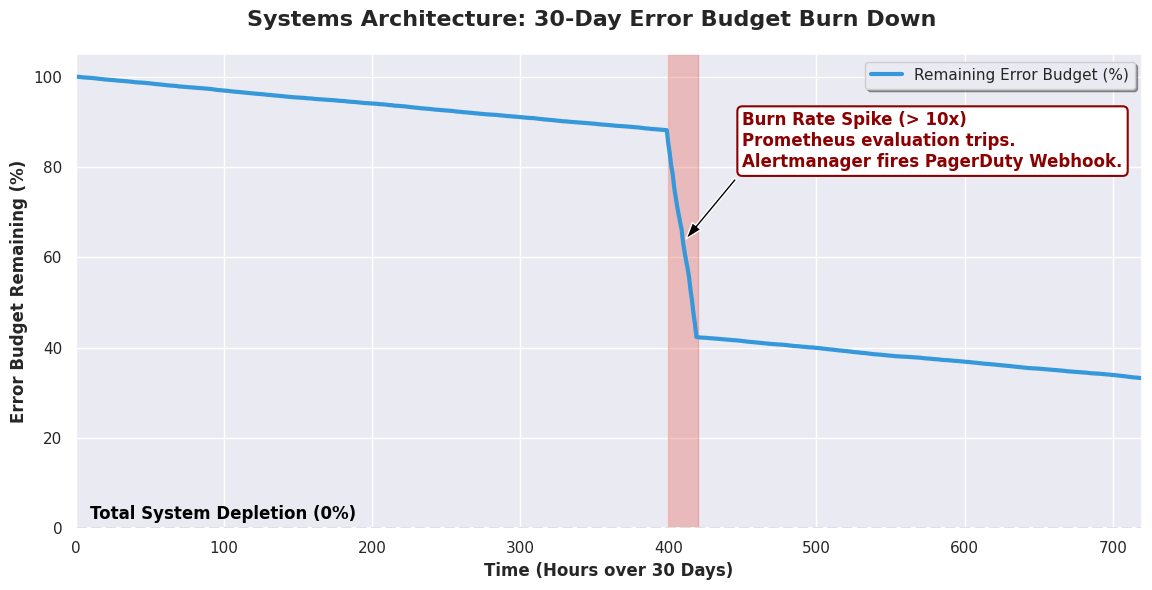

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

sns.set_theme(style="darkgrid")

# Create visual layout for Error Budget Burn
fig, ax = plt.subplots(figsize=(12, 6))
fig.suptitle("Systems Architecture: 30-Day Error Budget Burn Down", fontsize=16, fontweight='bold')

# Simulate 30 days of data (720 hours)
hours = np.arange(0, 720, 1)

# Start with 100% of the allowed monthly error budget
budget_remaining = np.zeros(720)
budget_remaining[0] = 100.0

# Simulate normal, healthy burn (tiny micro-failures that are acceptable)
for i in range(1, 400):
    budget_remaining[i] = budget_remaining[i-1] - np.random.uniform(0.01, 0.05)

# Simulate a CRITICAL outage (e.g., GPU node failure) starting at hour 400
for i in range(400, 420):
    budget_remaining[i] = budget_remaining[i-1] - np.random.uniform(1.5, 3.0)

# Simulate system recovery, but the budget is now permanently lower
for i in range(420, 720):
    budget_remaining[i] = budget_remaining[i-1] - np.random.uniform(0.01, 0.05)

# Plot the burn down trajectory
ax.plot(hours, budget_remaining, color='#3498db', linewidth=3, label='Remaining Error Budget (%)')

# Highlight the Rapid Burn Zone
ax.axvspan(400, 420, color='#e74c3c', alpha=0.3)
ax.annotate('Burn Rate Spike (> 10x)\nPrometheus evaluation trips.\nAlertmanager fires PagerDuty Webhook.', 
            xy=(410, budget_remaining[410]), xytext=(450, 80),
            arrowprops=dict(facecolor='black', shrink=0.05, width=2, headwidth=8),
            ha='left', fontweight='bold', color='darkred',
            bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="darkred", lw=1.5))

# Formatting
ax.set_xlabel('Time (Hours over 30 Days)', fontweight='bold')
ax.set_ylabel('Error Budget Remaining (%)', fontweight='bold')
ax.set_xlim(0, 720)
ax.set_ylim(0, 105)
ax.axhline(0, color='black', linewidth=2, linestyle='--')
ax.text(10, 2, "Total System Depletion (0%)", color='black', fontweight='bold')
ax.legend(loc='upper right', frameon=True, shadow=True)

plt.tight_layout()
plt.show()

*(Insight: At hour 400, the line drops vertically. The system still has 60% of its budget remaining, meaning the $30\text{-day}$ SLO is technically not breached yet. However, Prometheus calculates the derivative (the slope) and realizes that if this steep drop continues, the budget will be wiped out in hours. It alerts the engineering team instantly to stop the burn.)*


## Real-World Use Case or Analogy

Think of Error Budgets and Alertmanager like **Managing a High-Speed Cross-Country Road Trip**:

* **The SLA (The Absolute Law):** The police mandate you cannot drive faster than 75 MPH. If you hit 76 MPH, you get pulled over and lose your license. This is an inflexible absolute.
* **The Error Budget (The Gas Tank):** Your goal is to drive from New York to Los Angeles in 40 hours. You have exactly 30 gallons of gas (**The Error Budget**).
* **Normal Burn:** Driving normally burns 0.5 gallons an hour. You will make it to LA safely. No need to panic.
* **The Burn Rate Spike:** You hit the mountains in Colorado and suddenly start driving in a low gear. You are now burning 5 gallons an hour.


* **Alertmanager (The Dashboard Warning Light):**
* **Stupid Alerting (CPU > 80%):** A stupid car alarm would scream at you simply because the engine is working hard going up the mountain. You ignore it because you *need* the engine to work hard.
* **SRE Alerting (Burn Rate):** A smart car computer calculates the derivative. It sees you still have 15 gallons of gas left (plenty of gas right now), but it calculates that at 5 gallons/hour, you will run out of gas in 3 hours, stranding you in the desert 1,000 miles from LA. The warning light flashes furiously. It mathematically forces you to pull over and fix the fuel mixture *before* you run out of gas.